<a href="https://colab.research.google.com/github/helvetia1975/JAY_INFO4670_SPRING2026_ASSIGNMENT2/blob/main/INFO4670_Assignment_SMS_Spam_v4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 12: Assignment 4 — SMS Spam Detection

**Goal:** Apply the six-step classification workflow to a real dataset.
Predict whether an SMS message is spam or legitimate (ham) using text-based features.

---

## I. Assignment Objective

By completing this assignment, you will:
- Follow a complete classification pipeline on real-world data
- Engineer binary features from raw text
- Train and evaluate a Decision Tree and a Naive Bayes classifier
- Interpret a confusion matrix and choose the right evaluation metric
- Analyze model performance and reflect on possible improvements

---

## II. Dataset

**Source:** UCI SMS Spam Collection (5,572 real SMS messages, no login required)

| Column | Description | Example |
|---|---|---|
| `label` | Class label | `spam` or `ham` |
| `message` | Raw SMS text | "WINNER!! You have been selected..." |
| `spam` | Encoded label (1 = spam, 0 = ham) | 1 |

Load it with one line — no file upload needed:
```python
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip'
```

---

## III. Grading Rubric (Total = 100 points)

| Section | What is graded | Points |
|---|---|---|
| Step 1 — Problem definition | Q1a + Q1b + Q1c (written) | 10 |
| Step 2 — Explore the data | Code runs correctly (2B, 2C, 2D) | 15 |
| Step 3 — Feature engineering | Code (3B, 3C) + Q3a + Q3b + Q3c (written) | 20 |
| Step 4 — Split the data | Code (4A) + Q4a + Q4b (written) | 10 |
| Step 5 — Train models | Code: 5A + 5B + 5C + 5D (5 pts each) | 20 |
| Step 6 — Code (6A + 6B + 6C) | Each code block runs correctly (4 pts each) | 12 |
| Step 6 — Written (Q6a–Q6d) | Q6a (3) + Q6b (3) + Q6c (4) + Q6d (3) | 13 |
| **Total** | | **100** |

---

## IV. Steps to Complete

Follow the steps below in order.
Each code cell starts with `# Write your code here` — replace it with your implementation.


---
### Setup — Run this cell first (provided)

In [52]:
# This cell is provided — run it before starting
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
print('Setup complete!')


Setup complete!


---
## Step 1 — Define the Problem

Before writing any code, answer the questions below.
Your answers here should guide every metric decision you make in Step 6.

**Context:**
A mobile carrier wants an automated classifier to flag spam SMS messages
before they reach users. The two possible errors are:

| Error | What happens |
|---|---|
| False Positive | A real (ham) message gets blocked |
| False Negative | A spam message reaches the user |

### Q1 — Problem Definition *(10 points)*

**Q1a.** Which error is more costly in a real spam filter — False Positive or False Negative?
Give one concrete real-world consequence for each.

*Your answer:*
> In a business context, email advertisements may get flagged as fraud (false positive). This ultimately leads to less effective business procedures. An example of a real-world false negative would be that an individual opens a link from a fraudulent email and has their information leaked. In my opinion, a false negative is more costly.

**Q1b.** Based on Q1a, which metric should be your primary evaluation target?
Choose one: **Precision**, **Recall**, or **F1-Score**. Explain why.

*Your answer:*
> Recall would be my primary evaluation target because this metric measures how many false negatives are getting through. If this is low, it means my system's abiility to catch false negatives is low. Inversely, if this is high, my system's ability to catch false negatives is high as well.

**Q1c.** The spam rate in this dataset is about 13%.
What accuracy would a dummy model that always predicts "ham" achieve?
Is that number still misleading? Why?

*Your answer:*
> The dummy model would have an accuracy of 87%. This number is misleading because it does not catch any spam at all. This is an example of an "accuracy trap".


---
## Step 2 — Load and Explore the Data

### Step 2A — Load the dataset



In [53]:
import urllib.request, zipfile, io

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip'
print('Downloading UCI SMS Spam Collection...')
with urllib.request.urlopen(url) as r:
    zf = zipfile.ZipFile(io.BytesIO(r.read()))
    with zf.open('SMSSpamCollection') as f:
        raw = pd.read_csv(f, sep='\t', header=None, names=['label', 'message'])

raw['spam'] = (raw['label'] == 'spam').astype(int)
print(f'Loaded: {len(raw)} messages')
raw.head(6)


Loaded: 5572 messages


,label,message,spam
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0
5,spam,FreeMsg Hey there darling it's been 3 week's n...,1


### Step 2B — Class distribution

**Hint:** Print the count and percentage of spam and ham messages.
Plot a bar chart with spam count in red and ham count in blue.
Also run a dummy model (predict all ham) and print its Accuracy, Recall, and F1.
This proves the Accuracy Trap from Lecture 8.


Class distribution:
  Ham  (0): 4,825  (86.6%)
  Spam (1): 747  (13.4%)

Dummy model (always predict ham):
  Accuracy  = 86.6%  <-- misleadingly high
  Recall    = 0.0%  <-- catches zero spam
  F1-Score  = 0.0%


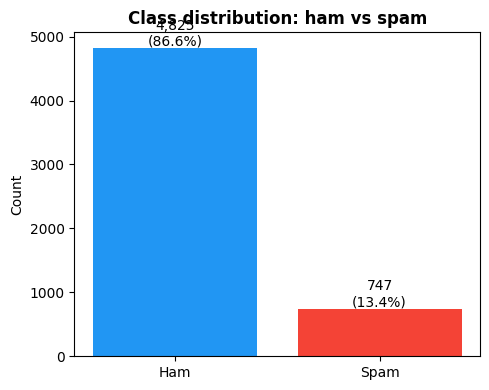

In [54]:
# Write your code here
spam_count = raw['spam'].sum()
ham_count  = (raw['spam'] == 0).sum()
spam_rate  = raw['spam'].mean()

print('Class distribution:')
print(f'  Ham  (0): {ham_count:,}  ({1-spam_rate:.1%})')
print(f'  Spam (1): {spam_count:,}  ({spam_rate:.1%})')
print()

# Prove the accuracy trap with a dummy model
y_all   = raw['spam'].values
y_dummy = np.zeros(len(y_all), dtype=int)
print(f'Dummy model (always predict ham):')
print(f'  Accuracy  = {accuracy_score(y_all, y_dummy):.1%}  <-- misleadingly high')
print(f'  Recall    = {recall_score(y_all, y_dummy, zero_division=0):.1%}  <-- catches zero spam')
print(f'  F1-Score  = {f1_score(y_all, y_dummy, zero_division=0):.1%}')

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Ham', 'Spam'], [ham_count, spam_count], color=['#2196F3', '#F44336'])
ax.set_ylabel('Count')
ax.set_title('Class distribution: ham vs spam', fontweight='bold')
for i, v in enumerate([ham_count, spam_count]):
    ax.text(i, v + 30, f'{v:,}\n({v/len(raw):.1%})', ha='center', fontsize=10)
plt.tight_layout()
plt.show()


### Step 2C — Read the raw text

**Hint:** Print 5 spam examples and 5 ham examples.
Limit each message to 130 characters using string slicing.


In [55]:
print('=== SPAM examples ===')
for i, msg in enumerate(raw[raw['spam']==1]['message'].head(5), 1):
    print(f'{i}. {msg[:130]}')
    print()

print('=== HAM examples ===')
for i, msg in enumerate(raw[raw['spam']==0]['message'].head(5), 1):
    print(f'{i}. {msg[:130]}')
    print()


=== SPAM examples ===
1. Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's 

2. FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to s

3. WINNER!! As a valued network customer you have been selected to receivea £900 prize reward! To claim call 09061701461. Claim code 

4. Had your mobile 11 months or more? U R entitled to Update to the latest colour mobiles with camera for Free! Call The Mobile Updat

5. SIX chances to win CASH! From 100 to 20,000 pounds txt> CSH11 and send to 87575. Cost 150p/day, 6days, 16+ TsandCs apply Reply HL 

=== HAM examples ===
1. Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...

2. Ok lar... Joking wif u oni...

3. U dun say so early hor... U c already then say...

4. Nah I don't think he goes to usf, he lives around here though

5. Even my b

### Step 2D — Message length analysis

**Hint:** Add a column `msg_length = message.str.len()`.
Print average length for spam and ham.
Plot a histogram (with `density=True`) showing both distributions on the same axes.


Average message length:
  Ham  : 71 characters
  Spam : 139 characters


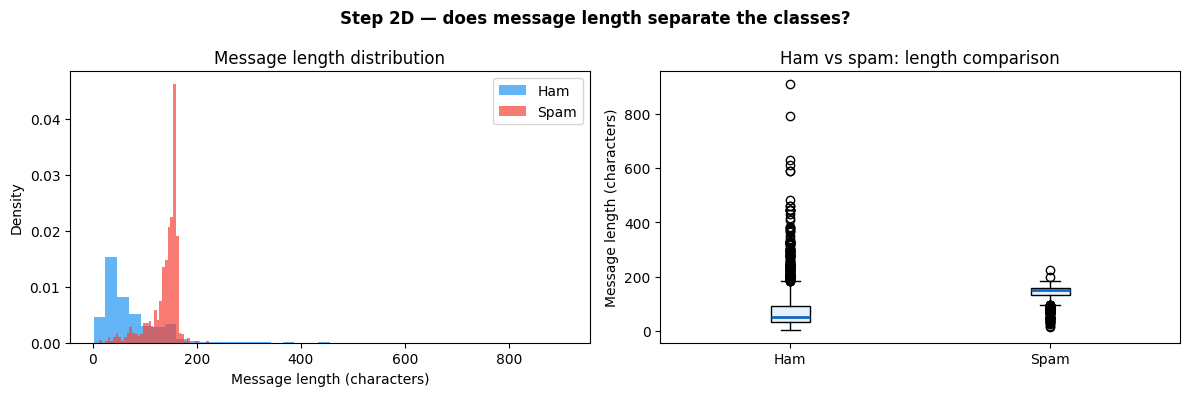

In [56]:
raw['msg_length'] = raw['message'].str.len()

print('Average message length:')
print(f'  Ham  : {raw[raw["spam"]==0]["msg_length"].mean():.0f} characters')
print(f'  Spam : {raw[raw["spam"]==1]["msg_length"].mean():.0f} characters')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(raw[raw['spam']==0]['msg_length'], bins=40, alpha=0.7,
             color='#2196F3', label='Ham', density=True)
axes[0].hist(raw[raw['spam']==1]['msg_length'], bins=40, alpha=0.7,
             color='#F44336', label='Spam', density=True)
axes[0].set_xlabel('Message length (characters)')
axes[0].set_ylabel('Density')
axes[0].set_title('Message length distribution')
axes[0].legend()

axes[1].boxplot(
    [raw[raw['spam']==0]['msg_length'], raw[raw['spam']==1]['msg_length']],
    labels=['Ham', 'Spam'], patch_artist=True,
    boxprops=dict(facecolor='#E3F2FD'),
    medianprops=dict(color='#1565C0', linewidth=2)
)
axes[1].set_ylabel('Message length (characters)')
axes[1].set_title('Ham vs spam: length comparison')
plt.suptitle('Step 2D — does message length separate the classes?', fontweight='bold')
plt.tight_layout()
plt.show()


---

---
## Step 3 — Feature Engineering

Raw text cannot go directly into a classifier.
Convert it into **binary features** (0 or 1) — the same format as the Hands-On Lab.

### Step 3A — Pre-built starter features
This cell is given to you. Run it and study the patterns before adding your own.


In [57]:
# This cell is provided — do not modify it
def build_features(df):
    d = df.copy()
    msg = d['message'].str.lower()

    d['has_phone'] = msg.str.contains(
        r'\b\d{3}[-.]?\d{3}[-.]?\d{4}\b|call.*\d{4,}|\b0\d{9,}\b',
        regex=True).astype(int)

    d['has_money'] = msg.str.contains(
        r'\b(free|win|winner|prize|cash|\$|claim|reward|won)\b',
        regex=True).astype(int)

    d['has_urgency'] = msg.str.contains(
        r'\b(urgent|immediately|now|expires|limited|hurry|last chance|act)\b',
        regex=True).astype(int)

    d['is_long'] = (d['message'].str.len() > 130).astype(int)
    return d

df = build_features(raw)
starter = ['has_phone', 'has_money', 'has_urgency', 'is_long']
print('Starter features (spam vs ham rate):')
print(f'{"Feature":<16} {"Spam%":>7} {"Ham%":>7} {"Gap":>7}')
print('-' * 42)
for f in starter:
    sp = df[df['spam']==1][f].mean()
    ha = df[df['spam']==0][f].mean()
    print(f'{f:<16} {sp:>7.1%} {ha:>7.1%} {sp-ha:>+7.1%}')


Starter features (spam vs ham rate):
Feature            Spam%    Ham%     Gap
------------------------------------------
has_phone          55.2%    0.1%  +55.1%
has_money          52.3%    2.0%  +50.3%
has_urgency        34.9%    6.4%  +28.5%
is_long            76.8%   14.2%  +62.7%


### Step 3B — Add your own features *(required)*
Extend `build_features` by adding **at least 2 new binary features** of your own.

**Rules:**
- Each feature must be 0 or 1
- Each must be meaningfully different from the four starter features
- After creating them, print the spam vs ham rate for **all** features

**Ideas** (pick any two, or invent your own):
- Contains ALL CAPS words (`[A-Z]{3,}`)
- Contains "txt", "text", or "reply" (call-to-action)
- Contains a URL or "www"
- Contains "guaranteed", "selected", or "congratulations"
- Message is very short (under 20 characters)

**Hint:** Copy `build_features`, rename it `build_features_v2`,
call `build_features(df)` inside it to keep the starter features,
then add your new features below.

At the end of the cell, run this line to collect all feature column names:
```python
feature_cols = [c for c in df.columns
                if c not in ['label', 'message', 'spam', 'msg_length']]
```
This variable is used in Steps 4, 5, and 6 — make sure it is defined here.


In [58]:
# Write your code here

def build_features_v2(df):
    d = build_features(df)   # keeps all 4 starter features
    msg = d['message'].str.lower()

    # --- Feature 5: add your first feature here ---
    # d['feature_name'] = msg.str.contains(r'...', regex=True).astype(int)
    d['has_caps'] = d['message'].str.contains(r'[A-Z]{3,}', regex=True).astype(int) # use "d['message']" to read original message; line above lowercases the email completely
    # --- Feature 6: add your second feature here ---
    # d['feature_name'] = ...
    d['has_url'] = msg.str.contains(r'http[s]?://|www\.', regex=True).astype(int)

    return d

df = build_features_v2(raw)

# Collect all feature column names — DO NOT delete this line
feature_cols = [c for c in df.columns
                if c not in ['label', 'message', 'spam', 'msg_length']]

# Print spam vs ham rate for all features
print('All features (spam vs ham rate):')
print(f'{"Feature":<20} {"Spam%":>7} {"Ham%":>7} {"Gap":>7}')
print('-' * 48)
for feat in feature_cols:
    sp = df[df['spam']==1][feat].mean()
    ha = df[df['spam']==0][feat].mean()
    print(f'{feat:<20} {sp:>7.1%} {ha:>7.1%} {sp-ha:>+7.1%}')


All features (spam vs ham rate):
Feature                Spam%    Ham%     Gap
------------------------------------------------
has_phone              55.2%    0.1%  +55.1%
has_money              52.3%    2.0%  +50.3%
has_urgency            34.9%    6.4%  +28.5%
is_long                76.8%   14.2%  +62.7%
has_caps               73.5%    7.2%  +66.3%
has_url                14.2%    0.0%  +14.1%


### Step 3C — Visualize feature gaps

**Hint:** Create one bar chart per feature (use `plt.subplots(1, n_features, ...)`).
Each bar chart shows two bars: spam rate (red) and ham rate (blue).
This is the same chart style used in the Hands-On Lab Step 0.


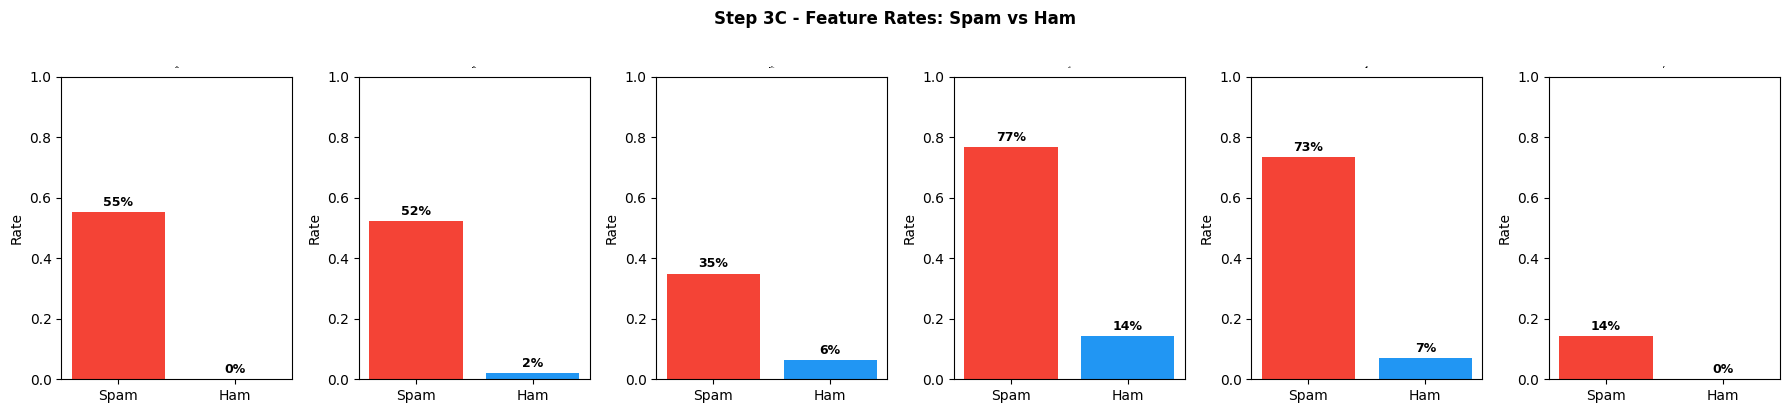

In [59]:
# Write your code here
n_features = len(feature_cols)
fig, axes = plt.subplots(1, n_features, figsize=(3 * n_features, 4))

for i, feat in enumerate(feature_cols):
  sp = df[df['spam']==1][feat].mean()
  ha = df[df['spam']==0][feat].mean()
  axes[i].bar(['Spam', 'Ham'], [sp, ha], color=['#F44336', '#2196F3'])
  axes[i].set_title(feat.replace('_', '\n'), fontsize=0, fontweight='bold')
  axes[i].set_ylim(0,1)
  axes[i].set_ylabel('Rate')
  for j, v in enumerate([sp, ha]):
    axes[i].text(j, v + 0.02, f'{v:.0%}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Step 3C - Feature Rates: Spam vs Ham', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Q3 — Feature Engineering *(20 points)*

**Q3a.** Describe the two features you added.
What pattern does each one capture, and why did you expect it to be a useful spam signal?

*Feature 1 — name and explanation:*
> "has_caps" is a feature that flags words that have three or more consecutive capitalized letters. Legitimate messages are unlikely to use 3+ consecutive capitals.

*Feature 2 — name and explanation:*
> "has_url" is  afeature that flags http/https or www links. Spam usually includes a phishing link.

**Q3b.** Which feature has the largest gap between spam and ham?
Why does a large gap matter when a Decision Tree selects its root node?
Connect your answer to the concept of **Information Gain** from Lecture 8.

*Your answer:*
> My "has_caps" feature has the biggest gap compared to all my features. Large gaps creates high information gain. Features with high information gain are split in order to reduce entropy the most, creating the purest child node.

**Q3c.** Look at the spam examples from Step 2C.
Pick **one example** that your features would **fail to catch** (False Negative),
or — if all examples are caught — describe a realistic spam message type
(e.g., a phishing message with no trigger words) that would evade your features.
State which specific feature(s) fail and explain why.

*Your answer:*
> The spam example "FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to s" would bypass my new features and the default features. "has_phone" would faul due to no phone number being present. "has_money" would fail since nothing in the message matches the regex exactly. "has_url" would fail since there are no URLs. "has_urgent" will fail since no keywords are used. "is_long" will fail due to the message being fairly short. "has_caps" would fail also since there are not three consecutive capitals in the message at all, but it does get close.


---
## Step 4 — Split the Data

### Step 4A — Train/Test split

**Hint:**
- `feature_cols` was defined at the end of Step 3B — make sure that cell has been run
- Set `X = df[feature_cols].values` and `y = df['spam'].values`
- Use `train_test_split` with `test_size=0.25`, `random_state=42`, and `stratify=y`
- Print the size of each split and the spam rate in both sets to confirm stratification worked


In [60]:
# Write your code here
X = df[feature_cols].values
y = df['spam'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f'Training set : {len(X_train):,} samples (spam rate: {y_train.mean():.1%})')
print(f'Test set: {len(X_test):,} samples (spam rate: {y_test.mean():.1%})')

Training set : 4,179 samples (spam rate: 13.4%)
Test set: 1,393 samples (spam rate: 13.4%)


### Q4 — Data Split *(10 points)*

**Q4a. (5 points)** Why do we pass `stratify=y`?
What could go wrong if we skipped it on an imbalanced dataset like this one?

*Your answer:*
> We pass "stratify-y" beacuse it preserves the 13% spam rate in the splits. Without it, random chance could put almost zero spam in the test set. This would make recall and F1 unreliable estiates of real-world performance.

**Q4b. (5 points)** We use a 75/25 train/test split.
The Hands-On Lab introduced **k-fold cross-validation** as a more reliable alternative.
Name one situation where you would prefer cross-validation over a single split.

*Your answer:*
> Cross-validation is best when a dataset is small. A single split can either get lucky or unlucky with which examples will land in the test set. K-fold passes all examples through both roles, giving it a more stable performance estimate.


---
## Step 5 — Train the Models （Each code 5 pts）

### Step 5A — Decision Tree

**Hint:**
- Use `DecisionTreeClassifier(max_depth=4, random_state=42, class_weight='balanced')`
- Fit on the training set
- Print the number of leaves with `.get_n_leaves()`
- Visualize the tree with `plot_tree(..., feature_names=..., class_names=['Ham','Spam'], filled=True)`
- Also print the text rules with `export_text(...)`


Number of leaves : 15
Max depth used : 4


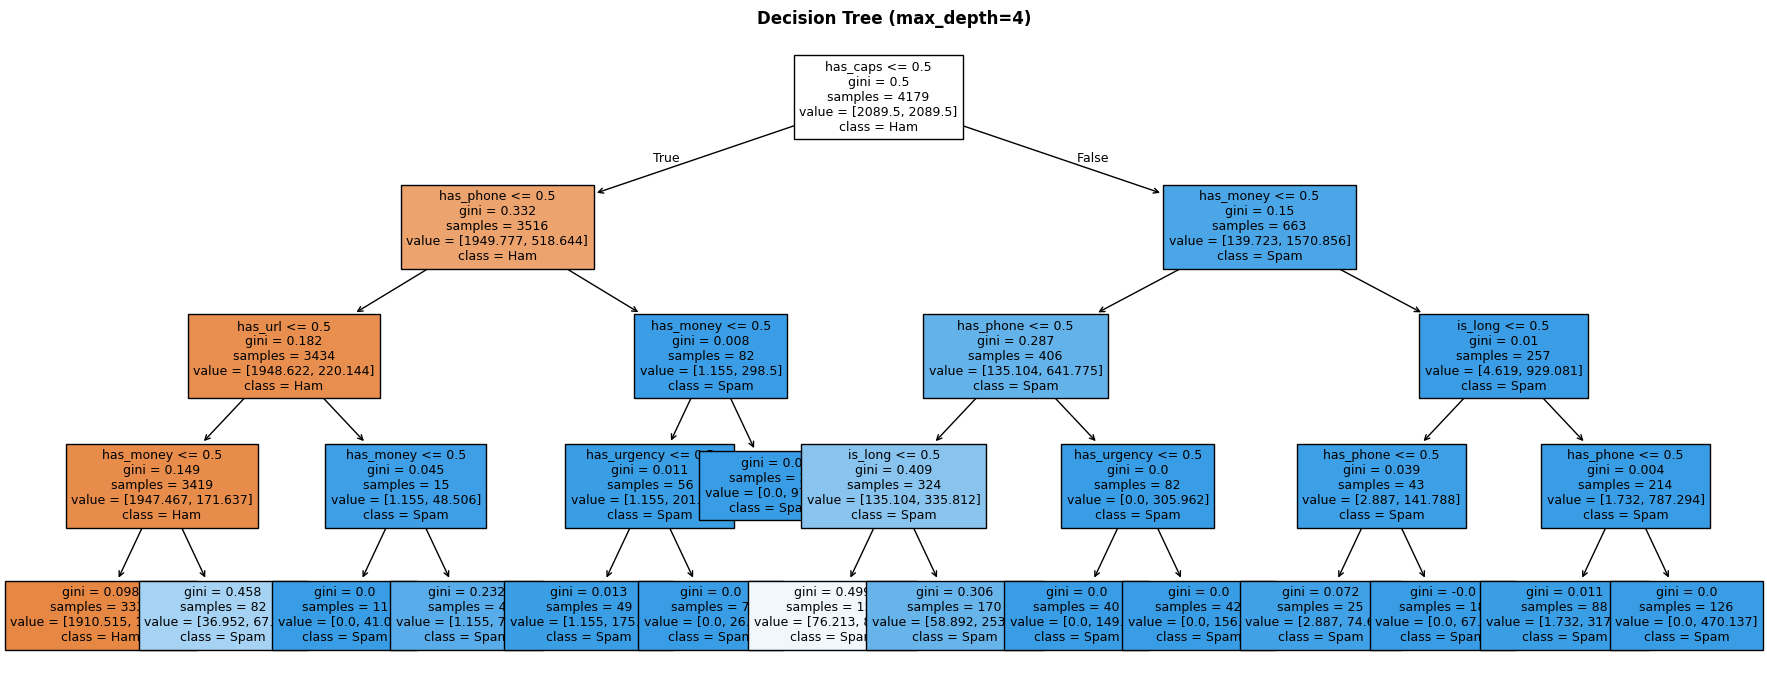

In [61]:
# Write your code here
dt = DecisionTreeClassifier(max_depth=4, random_state=42, class_weight='balanced')
dt.fit(X_train, y_train)

print(f'Number of leaves : {dt.get_n_leaves()}')
print(f'Max depth used : {dt.get_depth()}')

fig, ax = plt.subplots(figsize=(18, 7))
plot_tree(dt, feature_names=feature_cols, class_names=['Ham','Spam'], filled=True, fontsize=9, ax=ax)
ax.set_title('Decision Tree (max_depth=4)', fontweight='bold')
plt.tight_layout()
plt.show()

### Step 5B — Feature Importance

**Hint:**
- Get `.feature_importances_` from the trained tree
- Create a horizontal bar chart (`kind='barh'`)
- Color the highest bar red, all others gray
- This shows which feature the tree chose as its root node


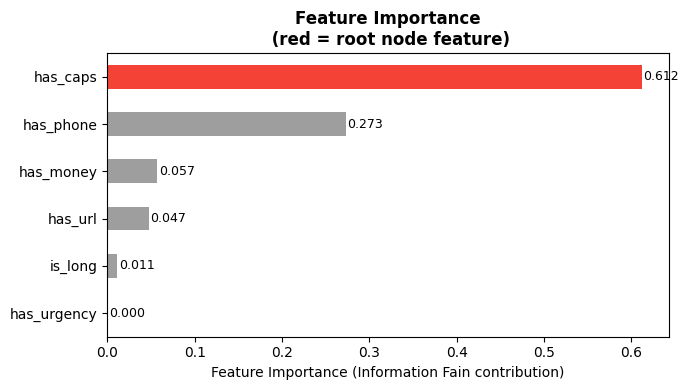

In [62]:
# Write your code here
importances = dt.feature_importances_
imp_series = pd.Series(importances, index=feature_cols).sort_values()

colors = ['#F44336' if feat == imp_series.idxmax() else '#9E9E9E' for feat in imp_series.index]

fig, ax = plt.subplots(figsize=(7, 4))
imp_series.plot(kind='barh', color=colors, ax=ax)
ax.set_xlabel('Feature Importance (Information Fain contribution)')
ax.set_title('Feature Importance\n (red = root node feature)', fontweight='bold')
for i, v in enumerate(imp_series):
  ax.text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

### Step 5C — Effect of Tree Depth

**Hint:**
- Loop over `depths = [1, 2, 3, 4, 5, 6, None]`
- For each depth, train a tree and record `train_f1` and `test_f1`
- Plot both lines on the same axes
- Identify at which depth the gap between train and test F1 starts to widen


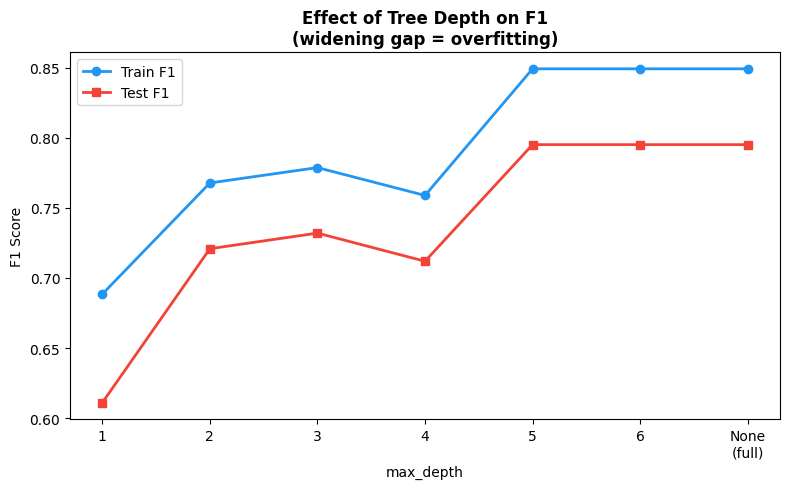

Best test F1 at max_depth=5: 0.795


In [63]:
# Write your code here
depths = [1, 2, 3, 4, 5, 6, None]
train_f1s, test_f1s = [], []

for d in depths:
  clf = DecisionTreeClassifier(max_depth=d, random_state=42, class_weight='balanced')
  clf.fit(X_train, y_train)
  train_f1s.append(f1_score(y_train, clf.predict(X_train)))
  test_f1s.append(f1_score(y_test, clf.predict(X_test)))

depth_labels = [str(d) if d is not None else 'None\n(full)' for d in depths]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(depth_labels, train_f1s, 'o-', color='#2196F3', label='Train F1', linewidth=2)
ax.plot(depth_labels, test_f1s, 's-', color='#F44336', label='Test F1', linewidth=2)
ax.set_xlabel('max_depth')
ax.set_ylabel('F1 Score')
ax.set_title('Effect of Tree Depth on F1\n(widening gap = overfitting)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

best_depth = depths[test_f1s.index(max(test_f1s))]
print(f'Best test F1 at max_depth={best_depth}: {max(test_f1s):.3f}')

### Step 5D — Naive Bayes

**Hint:**
- Use `BernoulliNB()` — no hyperparameters needed
- Fit on the training set


In [64]:
# Write your code here
nb_model = BernoulliNB()
nb_model.fit(X_train, y_train)
print('BernoulliNB trained.')
print(f'P(spam) prior: {y_train.mean():.1%}')
print(f'P(ham) prior: {1 - y_train.mean():.1%}')

BernoulliNB trained.
P(spam) prior: 13.4%
P(ham) prior: 86.6%


---
## Step 6 — Evaluate *(Each code block 4 points)*

### Step 6A — Confusion Matrices

**Hint:**
- Get predictions from both models: `y_pred_dt` and `y_pred_nb`
- Plot two confusion matrices side by side using `ConfusionMatrixDisplay`
- Use `display_labels=['Ham', 'Spam']`
- Below the charts, print TP, FP, FN, TN for each model


Model                 TP    FP    FN    TN
------------------------------------------
Decision Tree        173   126    14  1080
Naive Bayes          165    59    22  1147


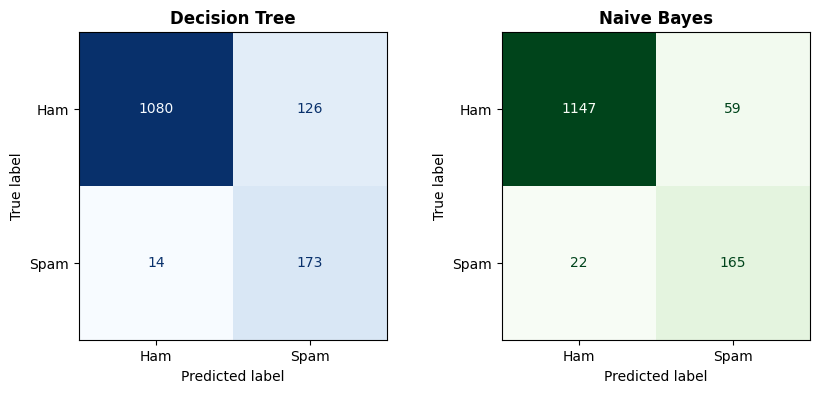

In [65]:
# Write your code here
y_pred_dt = dt.predict(X_test)
y_pred_nb = nb_model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_dt), display_labels=['Ham', 'Spam']).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Decision Tree', fontweight='bold')

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_nb), display_labels=['Ham', 'Spam']).plot(ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title('Naive Bayes', fontweight='bold')

print(f'{"Model":<18} {"TP":>5} {"FP":>5} {"FN":>5} {"TN":>5}')
print('-' * 42)
for name, preds in [('Decision Tree', y_pred_dt), ('Naive Bayes', y_pred_nb)]:
  tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
  print(f'{name:<18} {tp:>5} {fp:>5} {fn:>5} {tn:>5}')

### Step 6B — Metrics Comparison

**Hint:**
- Build a DataFrame with columns: Model, Accuracy, Precision, Recall, F1-Score
- One row per model
- Also create a grouped bar chart comparing all four metrics side by side


               Accuracy  Precision  Recall  F1-Score
Model                                               
Decision Tree    0.8995     0.5786  0.9251    0.7119
Naive Bayes      0.9419     0.7366  0.8824    0.8029


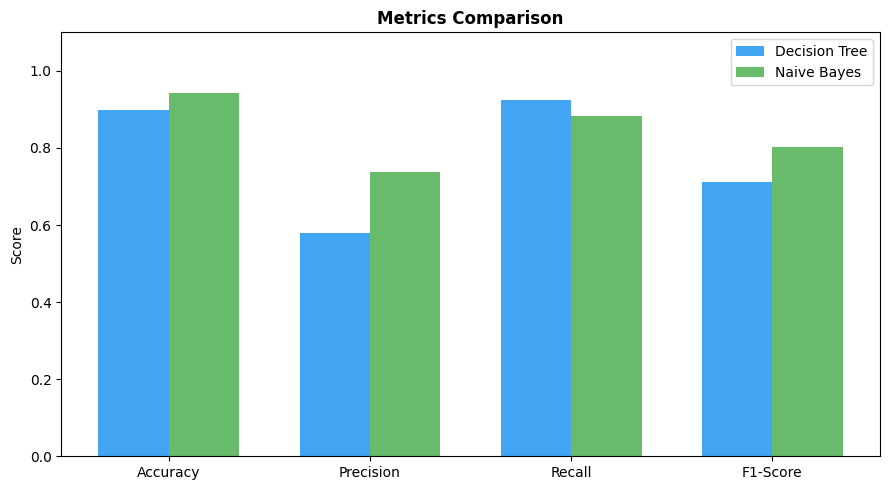

In [66]:
# Write your code here
rows = []
for name, preds in [('Decision Tree', y_pred_dt), ('Naive Bayes', y_pred_nb)]:
  rows.append({
      'Model': name,
      'Accuracy': accuracy_score(y_test, preds),
      'Precision': precision_score(y_test, preds),
      'Recall': recall_score(y_test, preds),
      'F1-Score': f1_score(y_test, preds)
  })
metrics_df = pd.DataFrame(rows).set_index('Model')
print(metrics_df.round(4).to_string())

metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metric_cols))
width = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, metrics_df.loc['Decision Tree', metric_cols], width, label='Decision Tree', color='#2196F3', alpha=0.85)
ax.bar(x + width/2, metrics_df.loc['Naive Bayes', metric_cols], width, label='Naive Bayes', color='#4CAF50', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(metric_cols)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Metrics Comparison', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### Step 6C — Cross-Validation

**Hint:**
- Use `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)`
- Run `cross_val_score` with `scoring='f1'` for both models
- Print the average F1 across 5 folds for each model


In [67]:
# Write your code here
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

dt_cv = cross_val_score(DecisionTreeClassifier(max_depth=4, random_state=42, class_weight='balanced'), X, y, cv=skf, scoring='f1')
nb_cv = cross_val_score(BernoulliNB(), X, y, cv=skf, scoring='f1')

print('5-Fold Cross-Validation F1:')
print(f'Decision Tree: mean= {dt_cv.mean():.3f} std={dt_cv.std():.3f} folds={[f"{s:.3f}" for s in dt_cv]}')
print(f'Naive Bayes: mean={nb_cv.mean():.3f} std={nb_cv.std():.3f} folds={[f"{s:.3f}" for s in nb_cv]}')

5-Fold Cross-Validation F1:
Decision Tree: mean= 0.799 std=0.044 folds=['0.763', '0.822', '0.853', '0.732', '0.824']
Naive Bayes: mean=0.832 std=0.010 folds=['0.833', '0.819', '0.845', '0.839', '0.824']


### Q6 — Evaluation & Analysis *(25 points)*

> **Points breakdown:**
> - Step 6A code (runs correctly): 4 pts
> - Step 6B code (runs correctly): 4 pts
> - Step 6C code (runs correctly): 4 pts
> - Q6a written: 3 pts
> - Q6b written: 3 pts
> - Q6c written: 4 pts
> - Q6d written: 3 pts
> - **Total: 25 pts**

---

**Q6a. Read the confusion matrices (Step 6A) — *(3 points)***

For each model, state:
- How many spam messages were correctly caught (True Positives)?
- How many spam messages slipped through (False Negatives)?
- How many legitimate messages were wrongly blocked (False Positives)?

*Decision Tree:*
> TP: 173
> FN: 14
> FP: 126

*Naive Bayes:*
> TP: 165
> FN: 22
> FP: 59

**Q6b. Apply your metric from Q1b — *(3 points)***

Which model wins on the metric you chose in Step 1?
By how much? Does the cross-validation result (Step 6C) confirm this?

*Your answer:*
> Decision Tree wins over Naive Bayes, 0.9251 to 0.8824, respectively. This is a difference of about 0.0427. However, cross-validation shows a different story. Naive Bayes has a mean F1 score of 0.832 with a small standard deviation of 0.010. Decision Tree has a mean F1 score of 0.799 with a higher standard deviation of 0.044. This means that the Decision Tree cross-validation proves that there is more variance in each fold. This means Naive Bayes is the more stable mode, and that its single-split recall is a truer reflection of real-world performance.

**Q6c. Recommendation memo — *(4 points)***

Imagine you are presenting to a product manager at a mobile carrier.
Write 4–5 sentences that:
1. State which model you recommend
2. Justify the choice with one specific number from your results
3. Acknowledge one weakness of your recommended model
4. Propose one concrete improvement

*Your memo:*
> I would recommend the Naive Bayes model. The 5-fold cross-validation for Naive Bayes has a mean F1 score of 0.832 with a standard deviation of 0.010. This means that across multiple test splits, it is a stable model compared to the Decision Tree model. One weakness is that it treats each feature as contributing separately. It can miss spam that only becomes suspicious after multiple weak signals appear at once. To improve it, I would include sender frequency patterns and a user feedback loop where reported spam can retrain the model periodically.

**Q6d. Generalization — *(3 points)***

The SMS Spam Collection was collected in the early 2010s.
Modern spam often uses professional language and legitimate-looking URLs.
Identify **two features you built** that would likely fail on modern spam, and explain why.

*Your answer:*
> "has_caps" would likely fail due to the use of professional language. In professional language, there is likely zero to very little consecutive capitals used. "has_urls" would also likely fail due to advancement of phishing techniques. They can use URL shorteners or hide links behind anchor text that does not look like a traditional URL.
